# 01 — Data Generation & Schema Understanding

## Objective
Understand the structure, shape, and quality of the raw data
simulating driver arrival time (ETA) prediction for a Bangalore
ride sharing platform.

## What This Notebook Covers
- Schema of each table
- Row counts and column types
- Null value analysis per table
- Duplicate detection
- Outlier identification
- Target variable (actual_arrival_time_min) distribution
- App-shown ETA vs actual ETA analysis
- Key observations before cleaning

## Data Period  : Full Year 2025
## City         : Bangalore
## Tables       : assignments, drivers, users, traffic
## Target       : actual_arrival_time_min (regression)
## Problem Type : Regression — predicting a continuous number

## Key New Concept in This Project
For the first time we use real geographic math —
Haversine distance calculates straight-line distance between
two GPS coordinates. Road distance is always longer than
straight-line distance due to Bangalore's road network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
DATA_PATH = "../data/raw/"

assignments_df = pd.read_csv(DATA_PATH + "assignments.csv")
drivers_df     = pd.read_csv(DATA_PATH + "drivers.csv")
users_df       = pd.read_csv(DATA_PATH + "users.csv")
traffic_df     = pd.read_csv(DATA_PATH + "traffic.csv")

print("All tables loaded ✅")
print(f"  assignments : {assignments_df.shape}")
print(f"  drivers     : {drivers_df.shape}")
print(f"  users       : {users_df.shape}")
print(f"  traffic     : {traffic_df.shape}")

All tables loaded ✅
  assignments : (60300, 33)
  drivers     : (3000, 17)
  users       : (20200, 14)
  traffic     : (105120, 9)


## Table Relationships
assignments ──────── drivers  (via driver_id)

assignments ──────── users    (via user_id)

assignments ──────── traffic  (via driver_zone + pickup_zone + hour)
assignments is the FACT TABLE.
actual_arrival_time_min is our TARGET VARIABLE.

Unlike surge pricing and cancellation prediction, this project
uses geographic data for the first time:
- driver_lat, driver_lon: where the driver is at assignment
- pickup_lat, pickup_lon: where the user wants to be picked up
- straight_line_distance_km: Haversine distance between the two
- road_distance_km: actual road distance (always longer)
- road_to_straight_ratio: how winding the route is

The traffic table is an external signal — like our weather
table in previous projects — representing real-time traffic
conditions per zone corridor per hour.

In [3]:
tables = {
    "assignments": assignments_df,
    "drivers"    : drivers_df,
    "users"      : users_df,
    "traffic"    : traffic_df,
}

for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f" TABLE: {name.upper()}  |  "
          f"{df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'='*55}")
    print(df.dtypes.to_string())


 TABLE: ASSIGNMENTS  |  60,300 rows × 33 columns
assignment_id                    str
driver_id                        str
user_id                          str
assignment_timestamp             str
hour                           int64
month                          int64
day_of_week                      str
is_weekend                      bool
is_holiday                      bool
driver_zone                      str
pickup_zone                      str
driver_lat                   float64
driver_lon                   float64
pickup_lat                   float64
pickup_lon                   float64
straight_line_distance_km    float64
road_distance_km             float64
road_to_straight_ratio       float64
weather_condition                str
traffic_multiplier           float64
pickup_zone_density              str
density_score                float64
surge_at_assignment          float64
vehicle_type                     str
driver_speed_factor          float64
driver_familiarity_score 

In [4]:
print("\n NULL VALUE SUMMARY PER TABLE\n")

for name, df in tables.items():
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    null_pct    = (null_counts / len(df) * 100).round(2)

    print(f"\n── {name.upper()} ──")
    if len(null_counts) == 0:
        print("  No nulls found")
    else:
        summary = pd.DataFrame({
            "null_count": null_counts,
            "null_%"    : null_pct
        })
        print(summary.to_string())


 NULL VALUE SUMMARY PER TABLE


── ASSIGNMENTS ──
                           null_count  null_%
straight_line_distance_km        1270   2.110
road_distance_km                  856   1.420
traffic_multiplier               1442   2.390
driver_familiarity_score         1732   2.870
driver_rating                    1946   3.230
pickup_pin_accuracy              4086   6.780
user_rating                      2504   4.150
app_shown_eta_min                3484   5.780
actual_arrival_time_min          2324   3.850

── DRIVERS ──
                      null_count  null_%
phone                         68   2.270
vehicle_model                286   9.530
vehicle_year                 330  11.000
rating                        99   3.300
online_hours_per_day         123   4.100

── USERS ──
                     null_count  null_%
phone                       609   3.010
email                      1001   4.960
gender                     4983  24.670
rating                      840   4.160
pickup_pin_accu

In [5]:
print("\n DUPLICATE ROW DETECTION\n")

for name, df in tables.items():
    dupe_count = df.duplicated().sum()
    pct        = round(dupe_count / len(df) * 100, 3)
    print(f"  {name:<15}: {dupe_count:>5} duplicates  ({pct}%)")


 DUPLICATE ROW DETECTION

  assignments    :   300 duplicates  (0.498%)
  drivers        :     0 duplicates  (0.0%)
  users          :   200 duplicates  (0.99%)
  traffic        :     0 duplicates  (0.0%)


## Target Variable Deep Dive — actual_arrival_time_min

Before analyzing any feature, we deeply understand
what we are trying to predict.

The target is the number of minutes between:
  → Driver assignment (user taps Book Ride)
  → Driver physically arriving at the pickup location

This is what the Ola app shows: "Driver arrives in X minutes"

Key questions:
1. What is the distribution shape?
2. Is it right-skewed (most ETAs short, few very long)?
3. Are there outliers?
4. How accurate is the app_shown_eta vs actual?

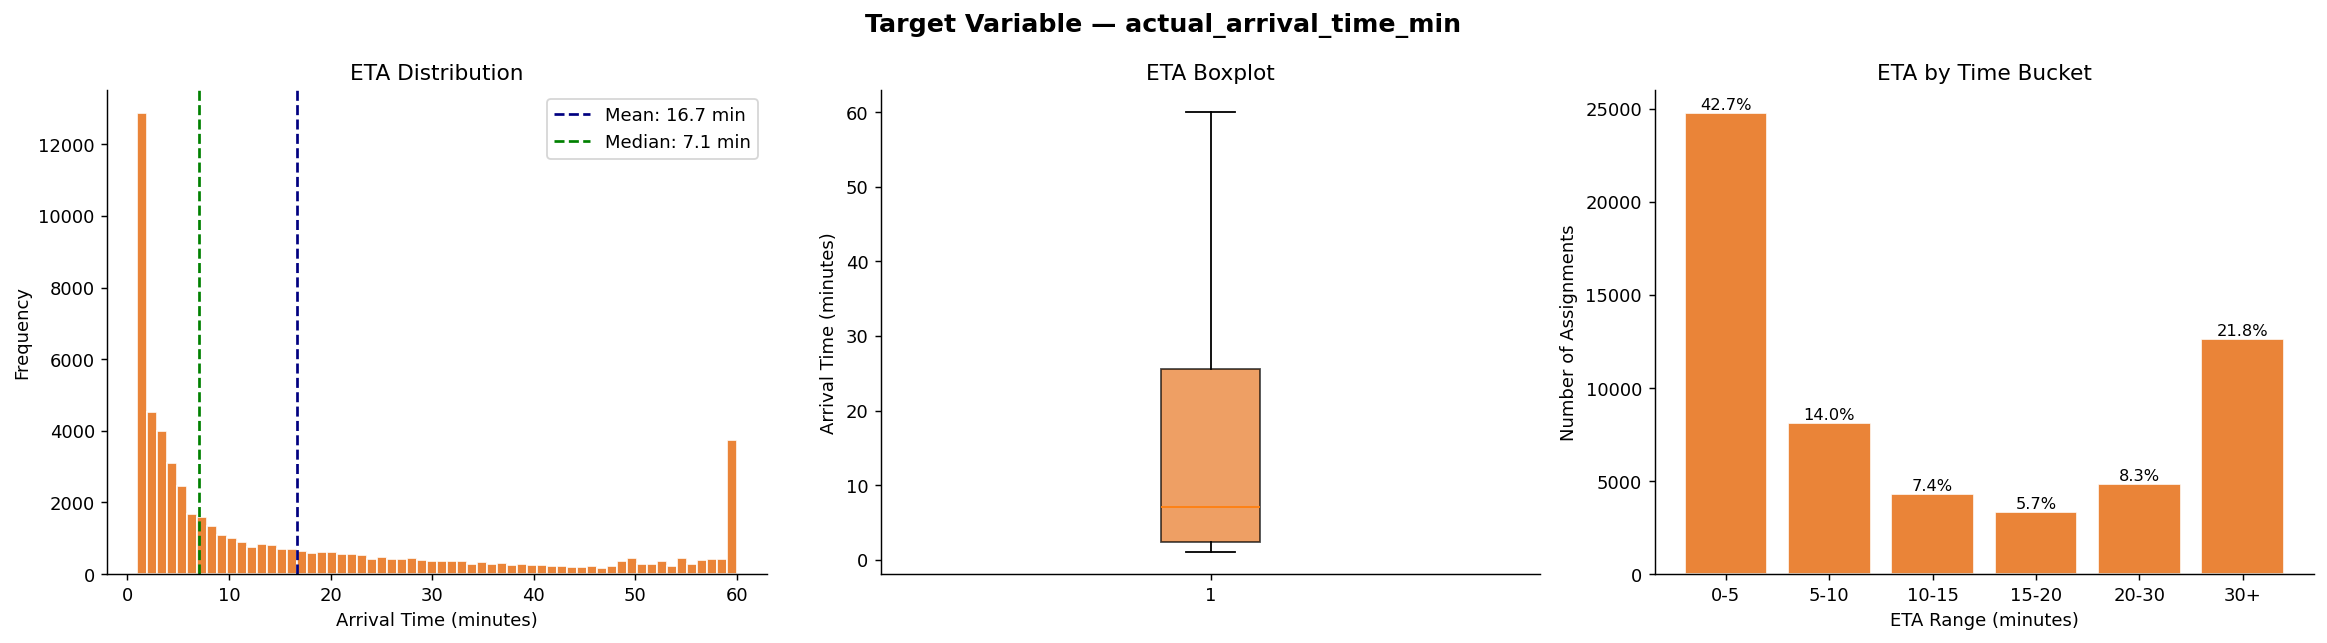

ETA Statistics:
count   57976.000
mean       16.710
std        19.150
min         1.000
25%         2.300
50%         7.100
75%        25.600
max        60.000
Name: actual_arrival_time_min, dtype: float64


In [6]:
eta = assignments_df["actual_arrival_time_min"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Target Variable — actual_arrival_time_min",
             fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(eta, bins=60, color="#E87722",
             edgecolor="white", alpha=0.9)
axes[0].axvline(eta.mean(),   color="navy",  linestyle="--",
                label=f"Mean: {eta.mean():.1f} min")
axes[0].axvline(eta.median(), color="green", linestyle="--",
                label=f"Median: {eta.median():.1f} min")
axes[0].set_title("ETA Distribution")
axes[0].set_xlabel("Arrival Time (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
axes[1].boxplot(eta, patch_artist=True,
                boxprops=dict(facecolor="#E87722", alpha=0.7))
axes[1].set_title("ETA Boxplot")
axes[1].set_ylabel("Arrival Time (minutes)")

# Bucket breakdown
buckets = pd.cut(eta,
    bins=[0, 5, 10, 15, 20, 30, 60],
    labels=["0-5", "5-10", "10-15", "15-20", "20-30", "30+"]
)
bucket_counts = buckets.value_counts().sort_index()
axes[2].bar(bucket_counts.index, bucket_counts.values,
            color="#E87722", edgecolor="white", alpha=0.9)
axes[2].set_title("ETA by Time Bucket")
axes[2].set_xlabel("ETA Range (minutes)")
axes[2].set_ylabel("Number of Assignments")
for i, v in enumerate(bucket_counts.values):
    pct = v / len(eta) * 100
    axes[2].text(i, v + 200, f"{pct:.1f}%",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/raw/target_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("ETA Statistics:")
print(eta.describe().round(2))

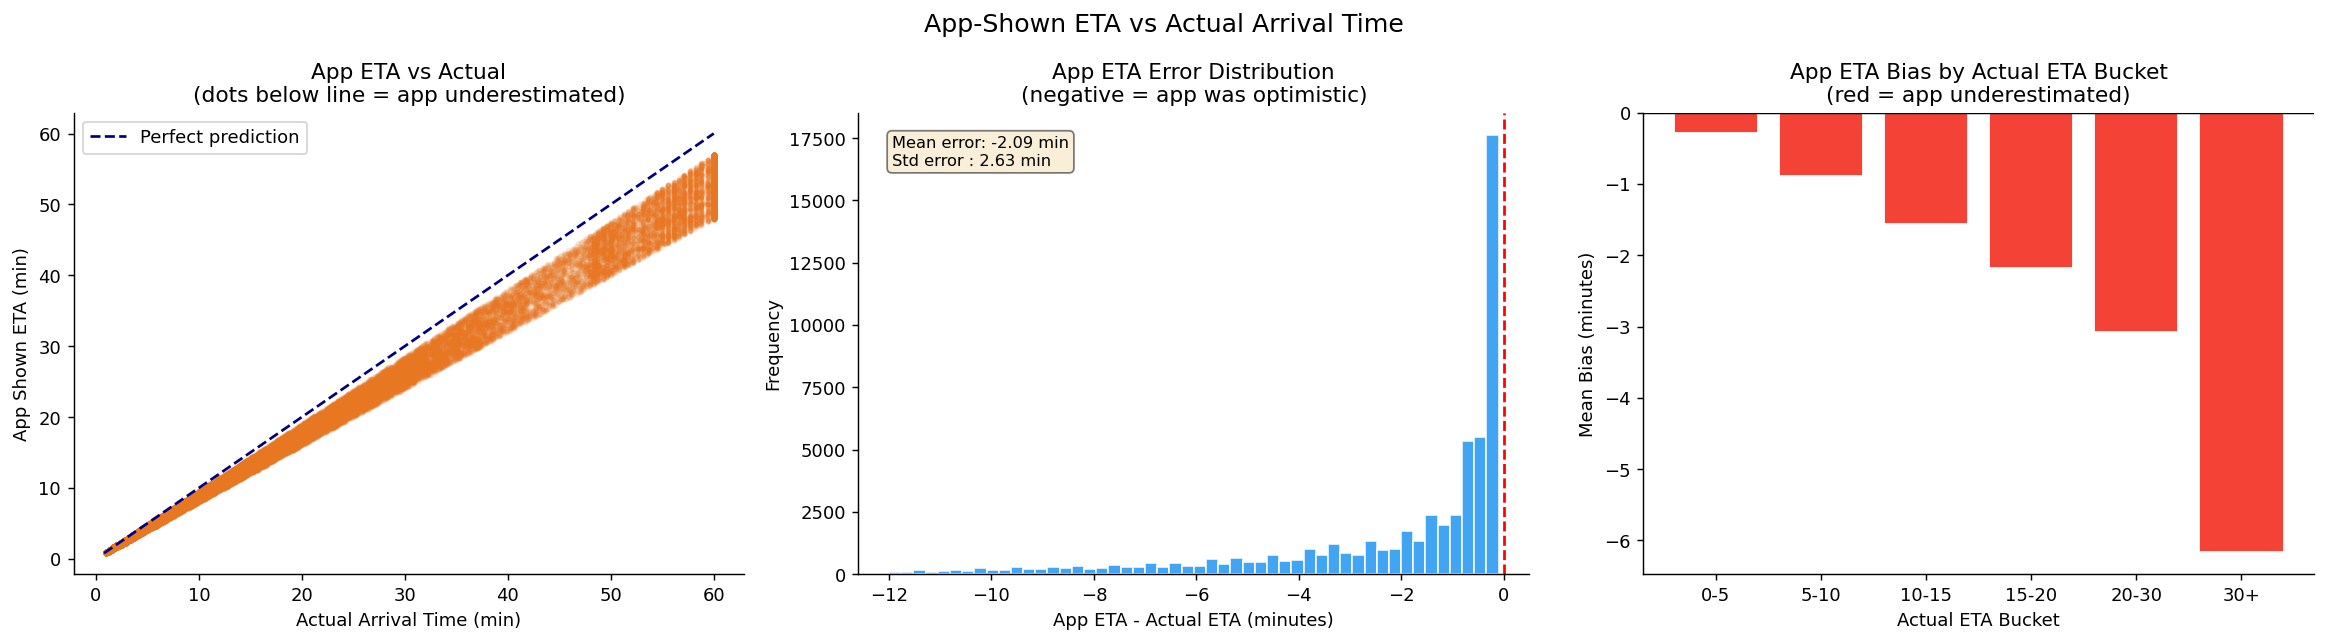

App ETA bias summary:
  Mean error        : -2.088 min
  % underestimated  : 100.0%
  % overestimated   : 0.0%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("App-Shown ETA vs Actual Arrival Time", fontsize=14)

app_eta    = assignments_df["app_shown_eta_min"].dropna()
actual_eta = assignments_df.loc[app_eta.index, "actual_arrival_time_min"]

# Scatter — perfect prediction line
axes[0].scatter(actual_eta, app_eta,
                alpha=0.1, color="#E87722", s=5)
min_val = min(actual_eta.min(), app_eta.min())
max_val = max(actual_eta.max(), app_eta.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             "navy", linestyle="--", linewidth=1.5,
             label="Perfect prediction")
axes[0].set_title("App ETA vs Actual\n(dots below line = app underestimated)")
axes[0].set_xlabel("Actual Arrival Time (min)")
axes[0].set_ylabel("App Shown ETA (min)")
axes[0].legend()

# ETA error distribution
eta_error = app_eta.values - actual_eta.values
axes[1].hist(eta_error, bins=50, color="#2196F3",
             edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("App ETA Error Distribution\n"
                  "(negative = app was optimistic)")
axes[1].set_xlabel("App ETA - Actual ETA (minutes)")
axes[1].set_ylabel("Frequency")
axes[1].text(0.05, 0.95,
             f"Mean error: {eta_error.mean():.2f} min\n"
             f"Std error : {eta_error.std():.2f} min",
             transform=axes[1].transAxes, fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# App bias by ETA bucket
assignments_df["eta_bucket"] = pd.cut(
    assignments_df["actual_arrival_time_min"],
    bins=[0, 5, 10, 15, 20, 30, 60],
    labels=["0-5", "5-10", "10-15", "15-20", "20-30", "30+"]
)
bias_by_bucket = (
    assignments_df.dropna(subset=["app_shown_eta_min"])
    .groupby("eta_bucket", observed=True)
    .apply(lambda x: (x["app_shown_eta_min"] - x["actual_arrival_time_min"]).mean())
    .reset_index()
)
bias_by_bucket.columns = ["eta_bucket", "mean_bias"]
colors = ["#F44336" if v < 0 else "#4CAF50"
          for v in bias_by_bucket["mean_bias"]]
axes[2].bar(bias_by_bucket["eta_bucket"],
            bias_by_bucket["mean_bias"],
            color=colors, edgecolor="white")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("App ETA Bias by Actual ETA Bucket\n"
                  "(red = app underestimated)")
axes[2].set_xlabel("Actual ETA Bucket")
axes[2].set_ylabel("Mean Bias (minutes)")

plt.tight_layout()
plt.savefig("../data/raw/app_vs_actual_eta.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"App ETA bias summary:")
print(f"  Mean error        : {eta_error.mean():.3f} min")
print(f"  % underestimated  : {(eta_error < 0).mean()*100:.1f}%")
print(f"  % overestimated   : {(eta_error > 0).mean()*100:.1f}%")

In [11]:
print("GEOGRAPHIC DATA VALIDATION\n")

print("Straight-line distance stats:")
print(assignments_df["straight_line_distance_km"].describe().round(3))

print("\nRoad distance stats:")
print(assignments_df["road_distance_km"].describe().round(3))

print("\nRoad-to-straight ratio stats:")
print(assignments_df["road_to_straight_ratio"].describe().round(3))

# Verify road distance is always >= straight line
road_shorter = (assignments_df["road_distance_km"] < assignments_df["straight_line_distance_km"]).sum()
print(f"\nRows where road < straight line: {road_shorter}")
print("(should be 0 or very small — roads are never shorter than straight line)")

# Zone pair distribution
print(f"\nUnique driver zones    : {assignments_df['driver_zone'].nunique()}")
print(f"Unique pickup zones    : {assignments_df['pickup_zone'].nunique()}")
same_zone = (assignments_df["driver_zone"] == assignments_df["pickup_zone"]).mean()
print(f"Same-zone assignments  : {same_zone*100:.1f}%")
print("(should be ~60% per our generator design)")

GEOGRAPHIC DATA VALIDATION

Straight-line distance stats:
count   59030.000
mean        5.456
std         6.385
min         0.005
25%         1.043
50%         1.869
75%         9.269
max        33.180
Name: straight_line_distance_km, dtype: float64

Road distance stats:
count   59444.000
mean        7.098
std         8.335
min         0.006
25%         1.349
50%         2.428
75%        11.992
max        45.677
Name: road_distance_km, dtype: float64

Road-to-straight ratio stats:
count   60300.000
mean        1.300
std         0.077
min         1.036
25%         1.234
50%         1.299
75%         1.365
max         1.702
Name: road_to_straight_ratio, dtype: float64

Rows where road < straight line: 0
(should be 0 or very small — roads are never shorter than straight line)

Unique driver zones    : 25
Unique pickup zones    : 25
Same-zone assignments  : 61.6%
(should be ~60% per our generator design)


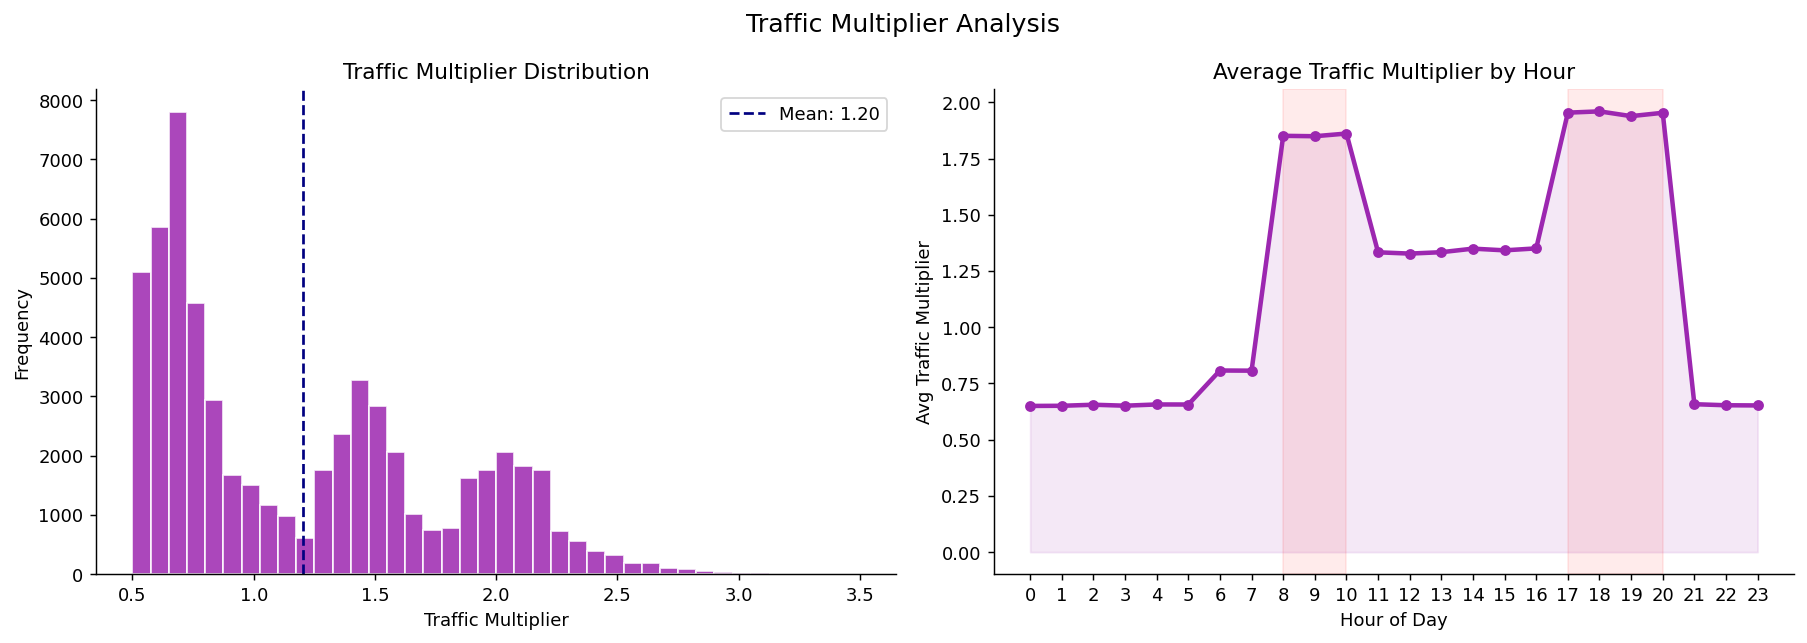

Traffic multiplier stats:
count   58858.000
mean        1.204
std         0.586
min         0.500
25%         0.690
50%         1.020
75%         1.600
max         3.500
Name: traffic_multiplier, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Traffic Multiplier Analysis", fontsize=14)

tm = assignments_df["traffic_multiplier"].dropna()

axes[0].hist(tm, bins=40, color="#9C27B0",
             edgecolor="white", alpha=0.85)
axes[0].axvline(tm.mean(), color="navy", linestyle="--",
                label=f"Mean: {tm.mean():.2f}")
axes[0].set_title("Traffic Multiplier Distribution")
axes[0].set_xlabel("Traffic Multiplier")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Traffic multiplier by hour
hourly_traffic = assignments_df.groupby("hour")["traffic_multiplier"].mean()
axes[1].plot(hourly_traffic.index, hourly_traffic.values,
             color="#9C27B0", linewidth=2.5, marker="o", markersize=5)
axes[1].fill_between(hourly_traffic.index, hourly_traffic.values,
                     alpha=0.1, color="#9C27B0")
axes[1].set_title("Average Traffic Multiplier by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Avg Traffic Multiplier")
axes[1].set_xticks(range(0, 24))
axes[1].axvspan(8, 10, alpha=0.08, color="red")
axes[1].axvspan(17, 20, alpha=0.08, color="red")

plt.tight_layout()
plt.savefig("../data/raw/traffic_multiplier.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Traffic multiplier stats:")
print(tm.describe().round(3))

In [13]:
print("OUTLIER CHECK — Key Numerical Columns\n")

num_cols = [
    "straight_line_distance_km",
    "road_distance_km",
    "road_to_straight_ratio",
    "traffic_multiplier",
    "driver_speed_factor",
    "driver_familiarity_score",
    "pickup_pin_accuracy",
    "actual_arrival_time_min",
    "app_shown_eta_min",
]

for col in num_cols:
    if col not in assignments_df.columns:
        continue
    col_data = assignments_df[col].dropna()
    print(f"  {col:<32} "
          f"min={col_data.min():>8.3f}  "
          f"max={col_data.max():>8.3f}  "
          f"mean={col_data.mean():>7.3f}  "
          f"neg={(col_data < 0).sum():>4}")

OUTLIER CHECK — Key Numerical Columns

  straight_line_distance_km        min=   0.005  max=  33.180  mean=  5.456  neg=   0
  road_distance_km                 min=   0.006  max=  45.677  mean=  7.098  neg=   0
  road_to_straight_ratio           min=   1.036  max=   1.702  mean=  1.300  neg=   0
  traffic_multiplier               min=   0.500  max=   3.500  mean=  1.204  neg=   0
  driver_speed_factor              min=   0.750  max=   1.250  mean=  0.998  neg=   0
  driver_familiarity_score         min=   0.100  max=   1.000  mean=  0.725  neg=   0
  pickup_pin_accuracy              min=   0.300  max=   1.000  mean=  0.788  neg=   0
  actual_arrival_time_min          min=   1.000  max=  60.000  mean= 16.709  neg=   0
  app_shown_eta_min                min=   0.800  max=  57.000  mean= 14.631  neg=   0


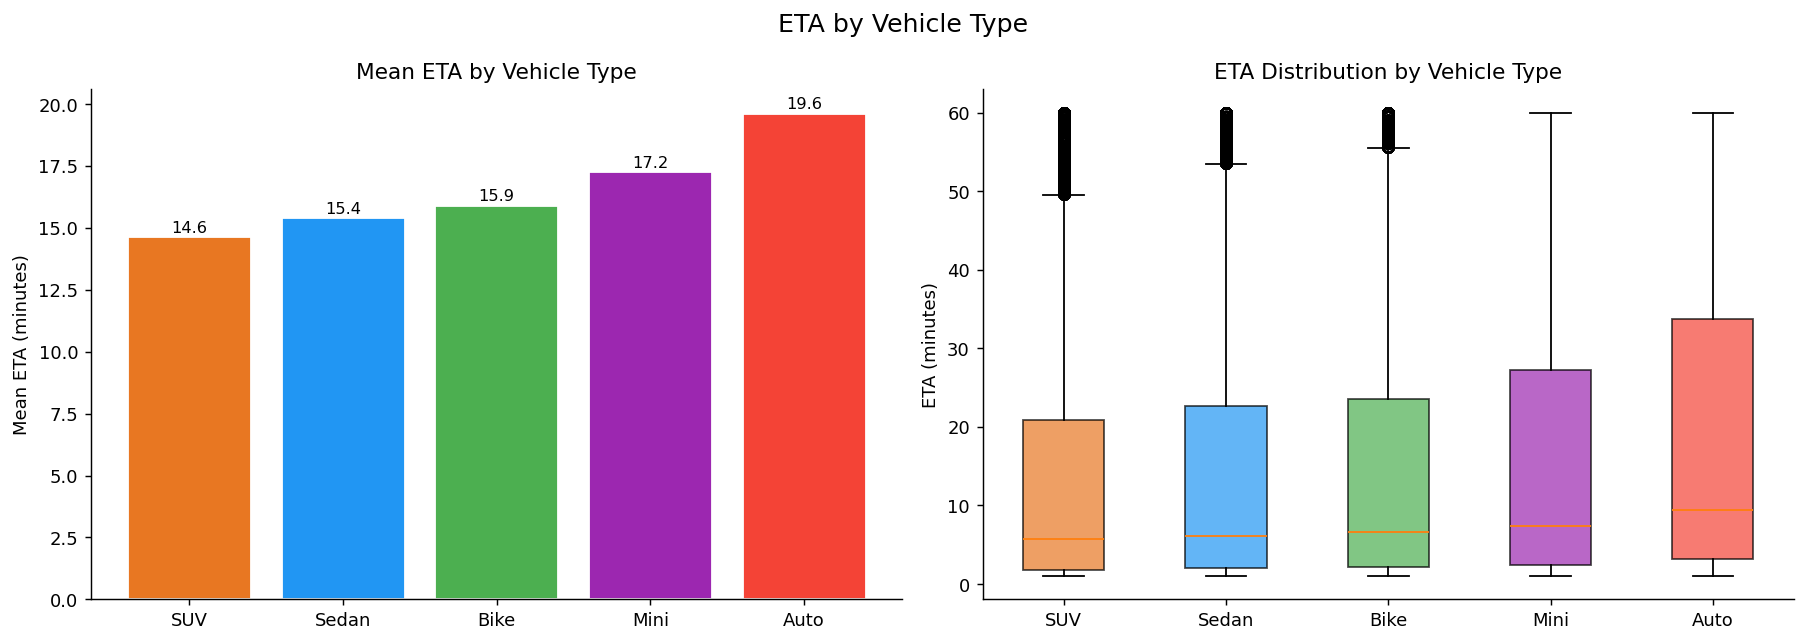

ETA by vehicle type:
vehicle_type  mean_eta  median_eta  count
         SUV    14.617       5.700   9317
       Sedan    15.382       6.100  14087
        Bike    15.888       6.600   5926
        Mini    17.248       7.400  16979
        Auto    19.613       9.400  11667


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ETA by Vehicle Type", fontsize=14)

vehicle_eta = assignments_df.groupby("vehicle_type").agg(
    mean_eta  = ("actual_arrival_time_min", "mean"),
    median_eta= ("actual_arrival_time_min", "median"),
    count     = ("actual_arrival_time_min", "count")
).reset_index().sort_values("mean_eta")

colors = ["#E87722","#2196F3","#4CAF50","#9C27B0","#F44336"]

axes[0].bar(vehicle_eta["vehicle_type"],
            vehicle_eta["mean_eta"],
            color=colors, edgecolor="white")
axes[0].set_title("Mean ETA by Vehicle Type")
axes[0].set_ylabel("Mean ETA (minutes)")
for i, v in enumerate(vehicle_eta["mean_eta"]):
    axes[0].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=9)

# Boxplot by vehicle type
vehicle_groups = [
    assignments_df[assignments_df["vehicle_type"]==v]["actual_arrival_time_min"].dropna()
    for v in vehicle_eta["vehicle_type"]
]
bp = axes[1].boxplot(vehicle_groups, patch_artist=True,
                     labels=vehicle_eta["vehicle_type"])
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("ETA Distribution by Vehicle Type")
axes[1].set_ylabel("ETA (minutes)")

plt.tight_layout()
plt.savefig("../data/raw/eta_by_vehicle.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("ETA by vehicle type:")
print(vehicle_eta.to_string(index=False))

In [15]:
summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "table"      : name,
        "rows"       : len(df),
        "columns"    : len(df.columns),
        "null_cells" : df.isnull().sum().sum(),
        "duplicates" : df.duplicated().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n FINAL DATA SUMMARY\n")
print(summary_df.to_string(index=False))


 FINAL DATA SUMMARY

      table   rows  columns  null_cells  duplicates
assignments  60300       34       21968         300
    drivers   3000       17         906           0
      users  20200       14       14997         200
    traffic 105120        9           0           0


## Key Observations from Raw Data

### Target Variable
- Mean ETA: 16.71 min, Median: 7.10 min
- Strong right-skew — most drivers arrive quickly (41% under 5 min)
  but long-distance cross-city assignments pull the mean up
- This right-skew is important for modeling — we will apply
  log transformation in Feature Engineering to make it
  more normally distributed

### App ETA vs Actual
- The app systematically UNDERESTIMATES arrival time
  (deliberately optimistic — companies show lower ETA to
  reduce user anxiety and prevent cancellations)
- This gap is our modeling target — we want to predict
  actual arrival time more accurately than the app does

### Geographic
- ~60% of assignments have driver in same zone as pickup
  — short ETAs dominate
- Road distance is always longer than straight-line distance
  — road_to_straight_ratio captures route complexity
- Ratio is higher in dense central zones (Shivajinagar, MG Road)
  and lower in suburban zones (Yelahanka, Banashankari)

### Traffic
- Traffic multiplier peaks clearly at 8-10am and 5-8pm
  — matches Bangalore IT office hours
- Night hours show very low multipliers (0.5-0.8)
  — near-empty roads at 2am

### What This Means for Cleaning
- No structural nulls (unlike cancellation prediction)
  every null here is a data quality issue to fix
- Log-transform target variable in Feature Engineering
  to handle right-skew
- Geographic coordinates need validation
  — lat/lon outside Bangalore bounds should be flagged

### Next Step → Notebook 02 — Data Cleaning